In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Data Import and Inicial Exploration

In [ ]:
# data import
path = Path("C:\\Users\\tobal\\Desktop\\Datasets\\GiveMeSomeCredit")
data = pd.read_csv(path / "cs-training.csv") # no tiene nombres de columnas
df = data.copy()

In [3]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
# Df description before cleaning
df.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

# Data Preparation

## DebtRatio 


In [6]:
# Debt ratio needs to be a value between 0 and 1, we check if there are any values above 1
(df["DebtRatio"] > 1).value_counts()

DebtRatio
False    114863
True      35137
Name: count, dtype: int64

In [7]:
(df["DebtRatio"] < 0).value_counts()

DebtRatio
False    150000
Name: count, dtype: int64

## Age

In [8]:
(df['age'] > 100).value_counts()


age
False    149987
True         13
Name: count, dtype: int64

In [9]:
(df['age'] < 21).value_counts()

age
False    149999
True          1
Name: count, dtype: int64

In [10]:
# There's only a few values of age that are greater than 100 and less than 18, so we can drop them without losing much information
df = df[(df['age'] >= 21) & (df['age'] <= 100)]

##  Number Of Time 30-59 and 90 Days Past Due Not Worse

In [17]:
# We check if the columns have some weird values
df['NumberOfTime30-59DaysPastDueNotWorse'].value_counts().sort_index()

NumberOfTime30-59DaysPastDueNotWorse
0     126006
1      16032
2       4597
3       1754
4        747
5        342
6        140
7         54
8         25
9         12
10         4
11         1
12         2
13         1
96         5
98       264
Name: count, dtype: int64

In [18]:
df['NumberOfTime60-89DaysPastDueNotWorse'].value_counts().sort_index()

NumberOfTime60-89DaysPastDueNotWorse
0     142382
1       5731
2       1118
3        318
4        105
5         34
6         16
7          9
8          2
9          1
11         1
96         5
98       264
Name: count, dtype: int64

In [19]:
df['NumberOfTimes90DaysLate'].value_counts().sort_index()

NumberOfTimes90DaysLate
0     141648
1       5243
2       1555
3        667
4        291
5        131
6         80
7         38
8         21
9         19
10         8
11         5
12         2
13         4
14         2
15         2
17         1
96         5
98       264
Name: count, dtype: int64

In [20]:
# We see that there are some values of 96 and 98, which are not possible, so we drop them
df = df[(df['NumberOfTime30-59DaysPastDueNotWorse'] < 96) & (df['NumberOfTime60-89DaysPastDueNotWorse'] < 96) & (df['NumberOfTimes90DaysLate'] < 96)]

# Nulls

In [21]:
df.isnull().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29603
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3890
dtype: int64

### For Number Of Dependents we are gonna assume that every null is equal to zero

In [60]:
# Value counts of NumberOfDependents
df["NumberOfDependents"].value_counts()

NumberOfDependents
0.0     86902
1.0     26316
2.0     19522
3.0      9483
4.0      2862
5.0       746
6.0       158
7.0        51
8.0        24
10.0        5
9.0         5
20.0        1
13.0        1
Name: count, dtype: int64

In [22]:
# Number of Dependents is gonna be filled with zeros, as it is the most common value 
df["NumberOfDependents"].fillna(df["NumberOfDependents"].mode()[0], inplace=True)

C:\Users\tobal\AppData\Local\Temp\ipykernel_10372\1844202973.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["NumberOfDependents"].fillna(df["NumberOfDependents"].mode()[0], inplace=True)


### Monthly Income is a bit more complex                        

In [64]:
(df["MonthlyIncome"] == 0).sum()

np.int64(1634)

In [65]:
# There are some values of MonthlyIncome that are zero, but we don't know if they are missing values or if they are actually zero
# In a model like this, it is better to consider them as missing values, as they are not likely to be zero, so we consider then as NaN
df["MonthlyIncome"].replace(0, np.nan, inplace=True)

C:\Users\tobal\AppData\Local\Temp\ipykernel_24468\4023967588.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["MonthlyIncome"].replace(0, np.nan, inplace=True)


In [66]:
# First, we create a flag for the missing values
df["MonthlyIncome_missing"] = df.MonthlyIncome.isnull().astype(int)

In [67]:
# Describe MonthlyIncome    
df.MonthlyIncome.describe()

count    1.186350e+05
mean     6.762092e+03
std      1.446194e+04
min      1.000000e+00
25%      3.500000e+03
50%      5.437000e+03
75%      8.300000e+03
max      3.008750e+06
Name: MonthlyIncome, dtype: float64

<Axes: xlabel='MonthlyIncome', ylabel='Count'>

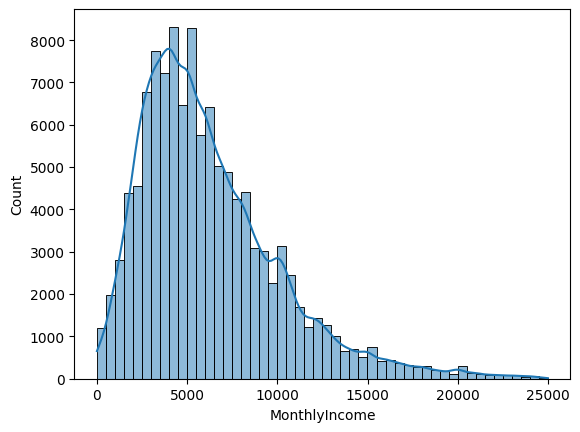

In [68]:
# We see that the variable presents some important outliers
# In order to be able to see the distribution, we delimit the df to the 99th percentile
monthly_income_99 = df.MonthlyIncome.quantile(0.99)
df_monthly_income_99 = df[df.MonthlyIncome < monthly_income_99]
sns.histplot(df_monthly_income_99.MonthlyIncome, bins=50, kde=True)


In [69]:
# We decide to fill the missing values of MonthlyIncome with the median, as it is a more robust measure of central tendency than the mean, and it is not affected by outliers
# df["MonthlyIncome"].fillna(df.MonthlyIncome.median(), inplace=True)

In [70]:
# monthly_income_99 = df.MonthlyIncome.quantile(0.99)
# df_monthly_income_99 = df[df.MonthlyIncome < monthly_income_99]
# sns.histplot(df_monthly_income_99.MonthlyIncome, bins=50, kde=True)

In [71]:
# We will utilize KNN imputer to fill the missing values of MonthlyIncome, as it is a more sophisticated method that takes into account the relationships between the variables, and it is not affected by outliers, as it uses the median of the neighbors to fill the missing values, instead of the mean
# from sklearn.impute import KNNImputer
# imputer = KNNImputer(n_neighbors=5)
# df_imputed = imputer.fit_transform(df)
# df_imputed = pd.DataFrame(df_imputed, columns=df.columns)
# # We check the distribution of MonthlyIncome after imputation
# monthly_income_99 = df_imputed.MonthlyIncome.quantile(0.99)
# df_monthly_income_99 = df_imputed[df_imputed.MonthlyIncome < monthly_income_99]
# sns.histplot(df_monthly_income_99.MonthlyIncome, bins=50, kde=True)

In [72]:
# # We fill the missing vallues utilizing the log of MonthlyIncome, as it is a more robust measure of central tendency than the mean, and it is not affected by outliers, as it uses the median of the neighbors to fill the missing values, instead of the mean
# df["MonthlyIncome_log"] = np.log1p(df["MonthlyIncome"])
# df["MonthlyIncome_log"].fillna(df.MonthlyIncome_log.median(), inplace=True)
# # Distribution of MonthlyIncome after filling the missing values with the log of MonthlyIncome
# monthly_income_log_99 = df.MonthlyIncome_log.quantile(0.99)
# df_monthly_income_log_99 = df[df.MonthlyIncome_log < monthly_income_log_99]
# sns.histplot(df_monthly_income_log_99.MonthlyIncome_log, bins=50, kde=True)

In [73]:
# # Re-transform MonthlyIncome_log to MonthlyIncome
# df["MonthlyIncome_filled"] = np.expm1(df["MonthlyIncome_log"])
# # Distribution of MonthlyIncome after filling the missing values with the log of MonthlyIncome and re-transforming it to MonthlyIncome
# monthly_income_filled_99 = df.MonthlyIncome_filled.quantile(0.99)
# df_monthly_income_filled_99 = df[df.MonthlyIncome_filled < monthly_income_filled_99]
# sns.histplot(df_monthly_income_filled_99.MonthlyIncome_filled, bins=50, kde=True)

C:\Users\tobal\AppData\Local\Temp\ipykernel_24468\2425287289.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["MonthlyIncome_log"].fillna(df.MonthlyIncome_log.median(), inplace=True)


<Axes: xlabel='MonthlyIncome_log', ylabel='Count'>

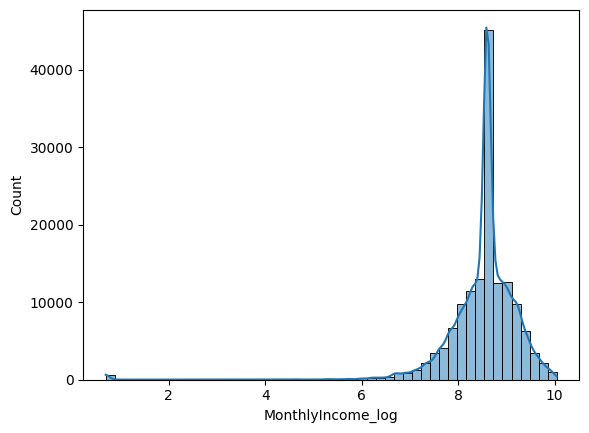

In [74]:
# Imputation of MonthlyIncome with the log of MonthlyIncome, as it is a more robust measure of central tendency than the mean, 
# and it is not affected by outliers, as it uses the median of the neighbors to fill the missing value
df["MonthlyIncome_log"] = np.log1p(df["MonthlyIncome"]) 
df["MonthlyIncome_log"].fillna(df.MonthlyIncome_log.median(), inplace=True)
# Distribution of MonthlyIncome after filling the missing values with the log of MonthlyIncome
monthly_income_log_99 = df.MonthlyIncome_log.quantile(0.99)
df_monthly_income_log_99 = df[df.MonthlyIncome_log < monthly_income_log_99]
sns.histplot(df_monthly_income_log_99.MonthlyIncome_log, bins=50, kde=True) 

In [75]:
# Revert   log
df["MonthlyIncome"] = np.expm1(df["MonthlyIncome_log"])

In [76]:
df.isnull().sum()

Unnamed: 0                              0
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
MonthlyIncome_missing                   0
MonthlyIncome_log                       0
dtype: int64

# Outliers Detection Income

<Axes: ylabel='MonthlyIncome'>

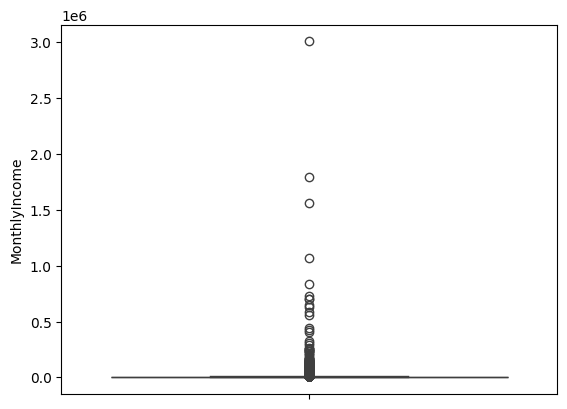

In [80]:
# We Check the outliers of Income
sns.boxplot(df.MonthlyIncome)

In [81]:
(df['MonthlyIncome'] > 500000).value_counts()

MonthlyIncome
False    149974
True         12
Name: count, dtype: int64

In [82]:
df.MonthlyIncome.quantile(0.9995)

np.float64(100000.00000000004)

In [83]:
# We create a cap variable for later
df_cap = df.copy()
df_cap = df_cap[df_cap.MonthlyIncome < df.MonthlyIncome.quantile(0.99)]

In [84]:
df_cap.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing,MonthlyIncome_log
count,148461.000000,148461.000000,148461.000000,148461.000000,148461.000000,148461.000000,148461.000000,148461.000000,148461.000000,148461.000000,148461.000000,148461.000000,148461.000000,148461.000000
mean,74993.188743,0.066967,5.621435,52.278228,0.421922,356.627163,6036.730023,8.420636,0.267545,1.007025,0.241707,0.731707,0.211220,8.522171
std,43299.140670,0.249966,210.562807,14.794513,4.206136,2048.027140,3393.143508,5.119192,4.183002,1.101527,4.168797,1.102838,0.408176,0.778858
min,1.000000,0.000000,0.000000,21.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.693147
25%,37493.000000,0.000000,0.029752,41.000000,0.000000,0.177794,4000.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.294300
50%,74981.000000,0.000000,0.154008,52.000000,0.000000,0.369871,5437.000000,8.000000,0.000000,1.000000,0.000000,0.000000,0.000000,8.601167
75%,112478.000000,0.000000,0.559892,63.000000,0.000000,0.887654,7226.000000,11.000000,0.000000,2.000000,0.000000,1.000000,0.000000,8.885579
max,150000.000000,1.000000,29110.000000,99.000000,98.000000,329664.000000,22956.000000,58.000000,98.000000,54.000000,98.000000,20.000000,1.000000,10.041378


In [85]:
df_cap.shape

(148461, 14)

In [ ]:
# IQR value counts
Q1 = df_cap.MonthlyIncome.quantile(0.25)
Q3 = df_cap.MonthlyIncome.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f'{(df_cap.MonthlyIncome < lower_bound).value_counts()}, {(df_cap.MonthlyIncome > upper_bound).value_counts()}')

# Feature Engineering

In [86]:
df_clean = df.copy()
df_clean["income_per_dependent"] = df_clean["MonthlyIncome"] / (df_clean["NumberOfDependents"] + 1)
df_clean["utilization_capped"] = df_clean["RevolvingUtilizationOfUnsecuredLines"].clip(0, 1)
df_clean['CreditHistoryLength'] = df_clean['age'] - 18  # Assuming credit starts at 18

# 2. Total Past Due Occurrences
df_clean['TotalPastDue'] = (
    df_clean['NumberOfTime30-59DaysPastDueNotWorse'] + 
    df_clean['NumberOfTime60-89DaysPastDueNotWorse'] + 
    df_clean['NumberOfTimes90DaysLate']
)

df_clean["weighted_late_score"] = (
    1 * df_clean["NumberOfTime30-59DaysPastDueNotWorse"] +
    1.5 * df_clean["NumberOfTime60-89DaysPastDueNotWorse"] +
    2.5 * df_clean["NumberOfTimes90DaysLate"])

df_clean['HasSeriousDelinquency'] = (df_clean['NumberOfTimes90DaysLate'] > 0).astype(int)


df_clean["high_utilization_flag"] = (df_clean["utilization_capped"] > 0.8).astype(int)
df_clean['AgeGroup'] = pd.cut(df_clean['age'], 
                               bins=[0, 25, 35, 45, 55, 65, 100],
                               labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+'])
df_clean['IncomeGroup'] = pd.qcut(df_clean['MonthlyIncome'].fillna(df_clean['MonthlyIncome'].median()), 
                                   q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'],
                                   duplicates='drop')

# 6. Debt-to-Income Ratio Category
df_clean['DTICategory'] = pd.cut(df_clean['DebtRatio'],
                                  bins=[0, 0.36, 0.43, 1, float('inf')],
                                  labels=['Low', 'Moderate', 'High', 'Very High'])

print("✅ Feature Engineering Complete")
print(f"New features created: {len(df_clean.columns) - len(df.columns)}")
print(f"Total features: {len(df_clean.columns)}")

✅ Feature Engineering Complete
New features created: 10
Total features: 24


In [87]:
# Statistical summary
print("📊 Statistical Summary:")
df_clean.describe()

📊 Statistical Summary:


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,...,NumberOfDependents,MonthlyIncome_missing,MonthlyIncome_log,income_per_dependent,utilization_capped,CreditHistoryLength,TotalPastDue,weighted_late_score,HasSeriousDelinquency,high_utilization_flag
count,149986.000000,149986.000000,149986.000000,149986.000000,149986.000000,149986.000000,1.499860e+05,149986.000000,149986.000000,149986.000000,...,149986.000000,149986.000000,149986.000000,1.499860e+05,149986.000000,149986.000000,149986.000000,149986.000000,149986.000000,149986.000000
mean,75000.499467,0.066840,6.048985,52.291101,0.421053,353.002995,6.485241e+03,8.452922,0.265998,1.018295,...,0.737462,0.209073,8.542527,4.641929e+03,0.319208,34.291101,0.927460,1.446662,0.055592,0.167556
std,43301.645266,0.249745,249.767020,14.764163,4.192973,2037.902441,1.287321e+04,5.146013,4.169498,1.129787,...,1.107048,0.406648,0.802400,7.962872e+03,0.349480,14.764163,12.466783,20.776540,0.229133,0.373472
min,1.000000,0.000000,0.000000,21.000000,0.000000,0.000000,1.000000e+00,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.693147,1.666667e-01,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.250000,0.000000,0.029878,41.000000,0.000000,0.175075,4.000000e+03,5.000000,0.000000,0.000000,...,0.000000,0.000000,8.294300,2.200000e+03,0.029878,23.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154234,52.000000,0.000000,0.366503,5.437000e+03,8.000000,0.000000,1.000000,...,0.000000,0.000000,8.601167,4.028000e+03,0.154234,34.000000,0.000000,0.000000,0.000000,0.000000
75%,112500.750000,0.000000,0.559053,63.000000,0.000000,0.868100,7.400000e+03,11.000000,0.000000,2.000000,...,1.000000,0.000000,8.909370,5.437000e+03,0.559053,45.000000,0.000000,0.000000,0.000000,0.000000
max,150000.000000,1.000000,50708.000000,99.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,...,20.000000,1.000000,14.917036,1.794060e+06,1.000000,81.000000,294.000000,490.000000,1.000000,1.000000


# EDA


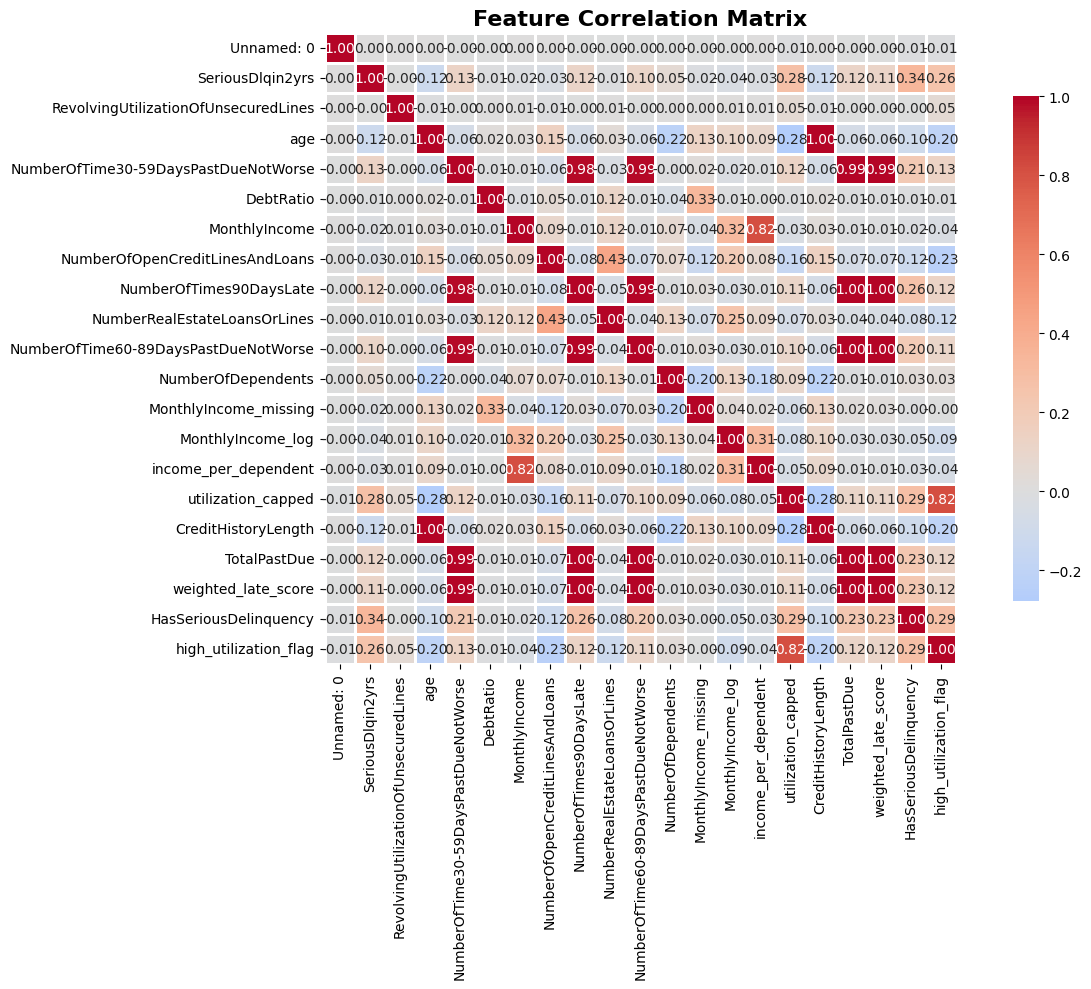


🎯 Top Correlations with Default:
HasSeriousDelinquency                   0.339595
utilization_capped                      0.278139
high_utilization_flag                   0.258640
NumberOfTime30-59DaysPastDueNotWorse    0.125582
NumberOfTimes90DaysLate                 0.117181
TotalPastDue                            0.115515
weighted_late_score                     0.114815
NumberOfTime60-89DaysPastDueNotWorse    0.102266
NumberOfDependents                      0.046878
Unnamed: 0                              0.002776
Name: SeriousDlqin2yrs, dtype: float64


In [88]:
# Correlation Analysis
fig, ax = plt.subplots(figsize=(14, 10))

# Select numeric columns only
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
correlation_matrix = df_clean[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Key correlations with target
target_corr = correlation_matrix['SeriousDlqin2yrs'].sort_values(ascending=False)
print("\n🎯 Top Correlations with Default:")
print(target_corr[1:11])  # Exclude target itself

In [34]:
# Non-linear relationships with dcor
import dcor
print("\n🔍 Non-linear Correlations with Default:")

# Compute non-linear correlations for all numeric features
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
target = df_clean['SeriousDlqin2yrs']

dcor_results = []
for col in numeric_cols:
    if col != 'SeriousDlqin2yrs':
        dcor_val = dcor.distance_correlation(df_clean[col], target)
        dcor_results.append((col, dcor_val))

# Sort by correlation value (descending)
dcor_results.sort(key=lambda x: x[1], reverse=True)

# Display top non-linear correlations
print("Top Non-linear Correlations:")
for col, corr in dcor_results[:10]:
    print(f"{col}: {corr:.4f}")


🔍 Non-linear Correlations with Default:


c:\Users\tobal\AppData\Local\Programs\Python\Python313\Lib\site-packages\dcor\_fast_dcov_avl.py:554: UserWarning: Falling back to uncompiled AVL fast distance covariance terms because of TypeError exception raised: No matching definition for argument type(s) array(int64, 1d, C), array(int64, 1d, C), bool. Rembember: only floating point values can be used in the compiled implementations.
  warnings.warn(
c:\Users\tobal\AppData\Local\Programs\Python\Python313\Lib\site-packages\dcor\_fast_dcov_avl.py:554: UserWarning: Falling back to uncompiled AVL fast distance covariance terms because of TypeError exception raised: No matching definition for argument type(s) array(float64, 1d, C), array(int64, 1d, C), bool. Rembember: only floating point values can be used in the compiled implementations.
  warnings.warn(


Top Non-linear Correlations:
HasSeriousDelinquency: 0.3396
utilization_capped: 0.2732
TotalPastDue: 0.2628
high_utilization_flag: 0.2586
weighted_late_score: 0.2578
NumberOfTime30-59DaysPastDueNotWorse: 0.2372
NumberOfTimes90DaysLate: 0.2251
NumberOfTime60-89DaysPastDueNotWorse: 0.1725
age: 0.1137
CreditHistoryLength: 0.1137


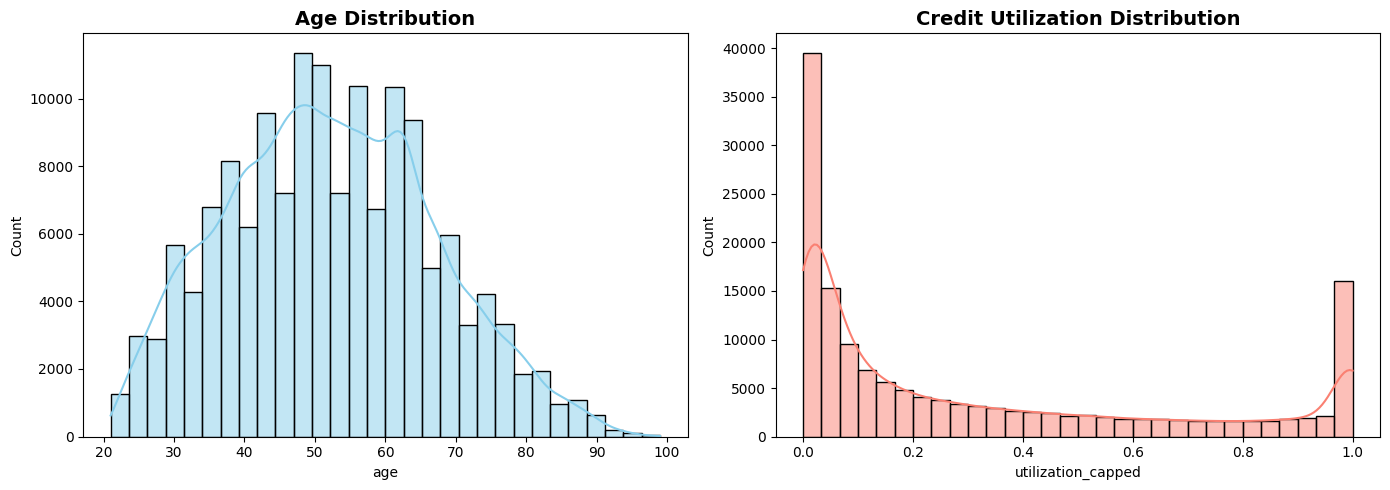

In [49]:
# Distribution of Age and Credit Utilization
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_clean['age'], bins=30, kde=True, ax=axes[0], color='skyblue')
sns.histplot(df_clean['utilization_capped'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[0].set_title('Age Distribution', fontsize=14, fontweight='bold')
axes[1].set_title('Credit Utilization Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()

In [50]:
# Normal test for Age
from scipy.stats import shapiro
stat, p = shapiro(df_clean['age'])
print(f"Shapiro-Wilk Test for Age: stat={stat:.4f}, p={p:.4f}")
if p > 0.05:
    print("Age distribution is approximately normal.")
else:
    print("Age distribution is not normal.")

Shapiro-Wilk Test for Age: stat=0.9906, p=0.0000
Age distribution is not normal.


c:\Users\tobal\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 149986.
  res = hypotest_fun_out(*samples, **kwds)


Text(0.5, 0, 'Age')

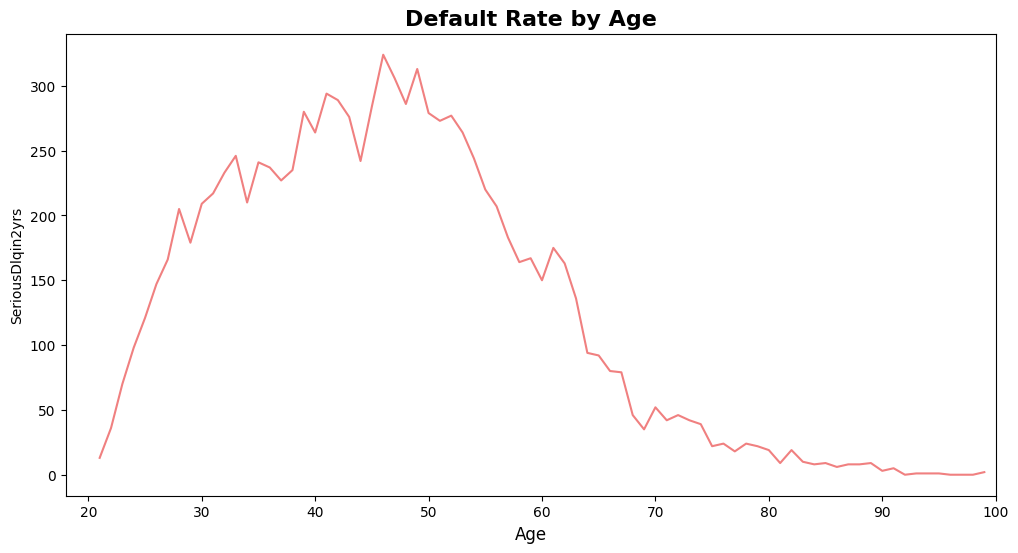

In [36]:
# Default per Age 
# Barplot and Lineplot
age_default_rate = df_clean.groupby('age')['SeriousDlqin2yrs'].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(x='age', y='SeriousDlqin2yrs', data=age_default_rate, color='lightcoral')
plt.title('Default Rate by Age', fontsize=16, fontweight='bold')
plt.xlim(18, 100)
plt.xlabel('Age', fontsize=12)

Text(0.5, 0, 'Age')

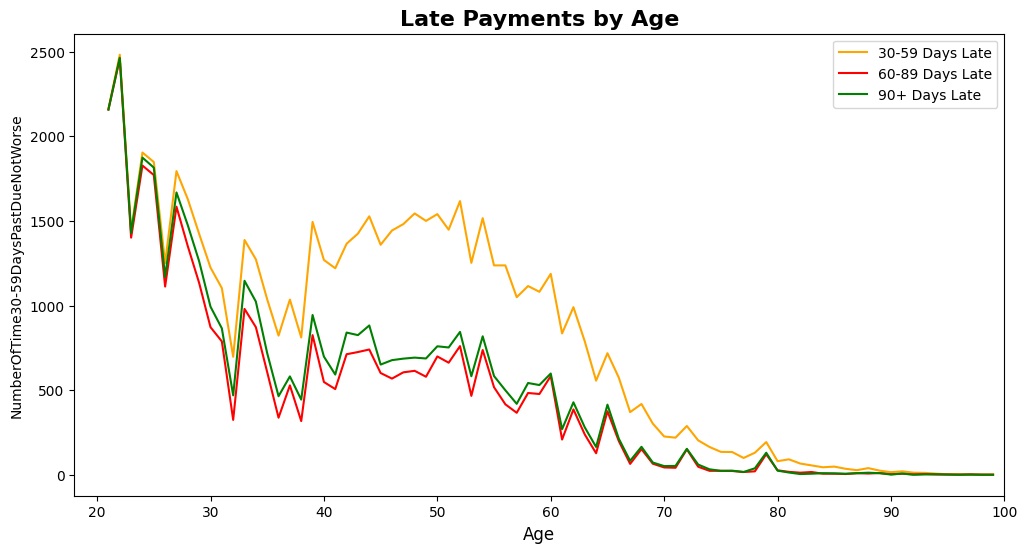

In [37]:
# 1 month-Late and 2 months-Late
late_1 = df_clean.groupby('age')["NumberOfTime30-59DaysPastDueNotWorse"].sum().reset_index()
late_2 = df_clean.groupby('age')["NumberOfTime60-89DaysPastDueNotWorse"].sum().reset_index()
late_3 = df_clean.groupby('age')["NumberOfTimes90DaysLate"].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(x='age', y='NumberOfTime30-59DaysPastDueNotWorse', data=late_1, label='30-59 Days Late', color='orange')
sns.lineplot(x='age', y='NumberOfTime60-89DaysPastDueNotWorse', data=late_2, label='60-89 Days Late', color='red')
sns.lineplot(x='age', y='NumberOfTimes90DaysLate', data=late_3, label='90+ Days Late', color='green')
plt.title('Late Payments by Age', fontsize=16, fontweight='bold')
plt.xlim(18, 100)
plt.xlabel('Age', fontsize=12)

C:\Users\tobal\AppData\Local\Temp\ipykernel_10356\1123638107.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_df = df_clean.groupby('AgeGroup')['SeriousDlqin2yrs'].sum().reset_index()
C:\Users\tobal\AppData\Local\Temp\ipykernel_10356\1123638107.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  thirtydays_late_group_df = df_clean.groupby('AgeGroup')["NumberOfTime30-59DaysPastDueNotWorse"].sum().reset_index()
C:\Users\tobal\AppData\Local\Temp\ipykernel_10356\1123638107.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass 

Text(0.5, 1.0, 'Default Rate by Age Group')

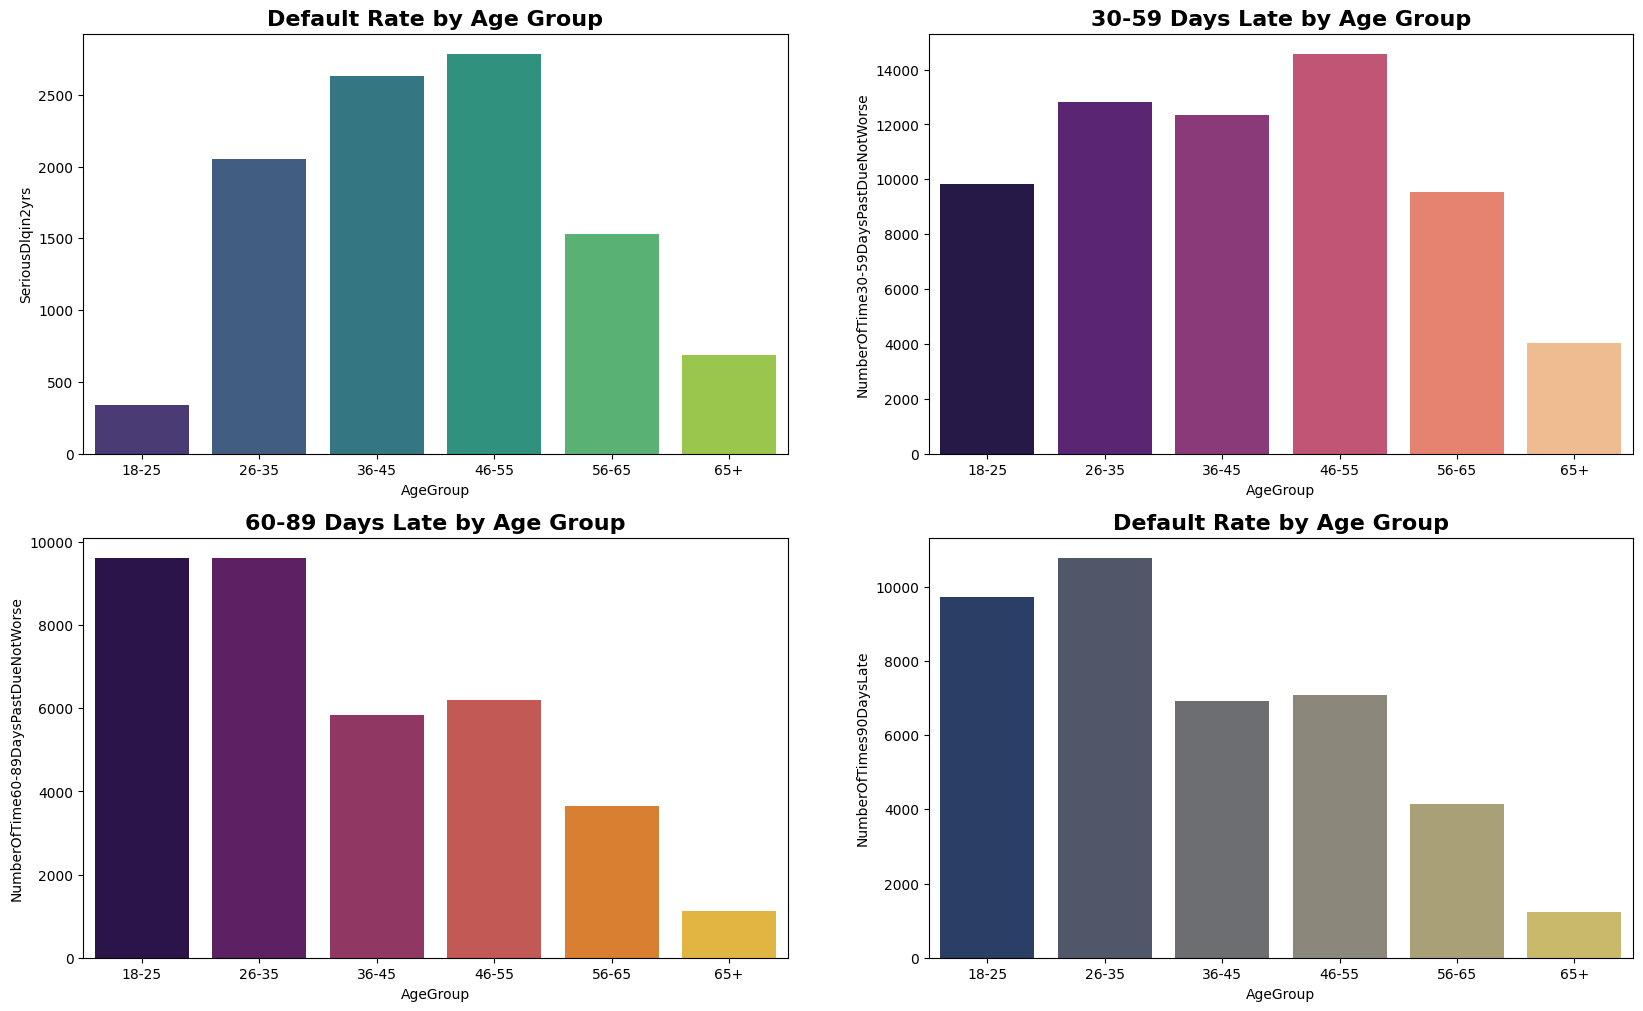

In [38]:
# Deafult per Age Group
age_group_df = df_clean.groupby('AgeGroup')['SeriousDlqin2yrs'].sum().reset_index()
thirtydays_late_group_df = df_clean.groupby('AgeGroup')["NumberOfTime30-59DaysPastDueNotWorse"].sum().reset_index()
sixtydays_late_group_df = df_clean.groupby('AgeGroup')["NumberOfTime60-89DaysPastDueNotWorse"].sum().reset_index()
ninetydays_late_group_df = df_clean.groupby('AgeGroup')["NumberOfTimes90DaysLate"].sum().reset_index()
fig2, axes2 = plt.subplots(2, 2, figsize=(20, 12))
sns.barplot(x='AgeGroup', y='SeriousDlqin2yrs', data=age_group_df, palette='viridis', ax = axes2[0,0])
sns.barplot(x='AgeGroup', y='NumberOfTime30-59DaysPastDueNotWorse', data=thirtydays_late_group_df, palette='magma', ax=axes2[0, 1])
sns.barplot(x='AgeGroup', y='NumberOfTime60-89DaysPastDueNotWorse', data=sixtydays_late_group_df, palette='inferno', ax=axes2[1, 0])
sns.barplot(x='AgeGroup', y='NumberOfTimes90DaysLate', data=ninetydays_late_group_df, palette='cividis', ax=axes2[1, 1])
axes2[0,0].set_title('Default Rate by Age Group', fontsize=16, fontweight='bold')
axes2[0, 1].set_title('30-59 Days Late by Age Group', fontsize=16, fontweight='bold')
axes2[1, 0].set_title('60-89 Days Late by Age Group', fontsize=16, fontweight='bold')
axes2[1, 1].set_title('90+ Days Late by Age Group', fontsize=16, fontweight='bold')    
plt.title('Default Rate by Age Group', fontsize=16, fontweight='bold')

# Model Development


C:\Users\tobal\AppData\Local\Temp\ipykernel_10356\1015710359.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='SeriousDlqin2yrs', data=df_clean, palette='Set2')


Text(0.5, 1.0, 'Class Distribution of Default')

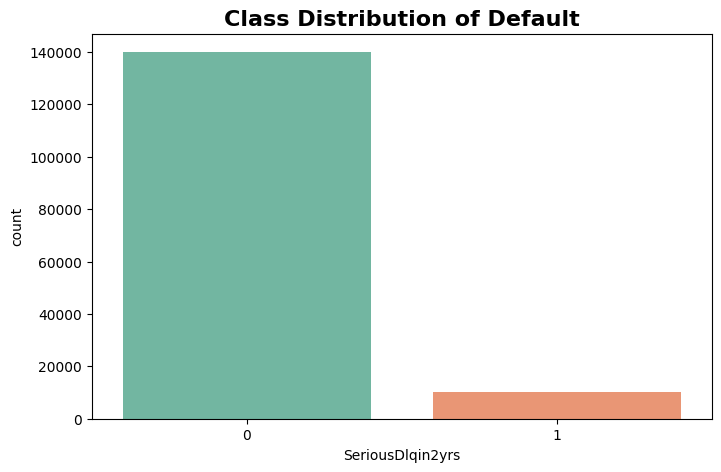

In [39]:
# Class balance
plt.figure(figsize=(8, 5))
sns.countplot(x='SeriousDlqin2yrs', data=df_clean, palette='Set2')
plt.title('Class Distribution of Default', fontsize=16, fontweight='bold')

In [40]:
# Numerically %
df_clean['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

SeriousDlqin2yrs
0    93.316043
1     6.683957
Name: proportion, dtype: float64

### Logistic

In [41]:
# First we try with modelling a simple model, logistic regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [42]:
# Train Test Split
X = df_clean.drop(columns=['SeriousDlqin2yrs'])
X = pd.get_dummies(X, drop_first=True)
y = df_clean['SeriousDlqin2yrs']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [43]:
# Logistic Model

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

c:\Users\tobal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [44]:
y_pred = model.predict(X_test)
accuracy = model.score(X_test, y_test)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
print(f"ROC AUC Score: {roc_auc:.4f}")

Accuracy: 0.7879
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.79      0.87     28023
           1       0.19      0.71      0.31      1975

    accuracy                           0.79     29998
   macro avg       0.58      0.75      0.59     29998
weighted avg       0.92      0.79      0.84     29998

Confusion Matrix:
[[22238  5785]
 [  577  1398]]
ROC AUC Score: 0.8185


In [45]:
# Prob predictions 50%
y_prob = model.predict_proba(X_test)[:, 1]
y_pred_50 = (y_prob >= 0.5).astype(int)
print("Classification Report at 50% Threshold:")
print(classification_report(y_test, y_pred_50))

Classification Report at 50% Threshold:
              precision    recall  f1-score   support

           0       0.97      0.79      0.87     28023
           1       0.19      0.71      0.31      1975

    accuracy                           0.79     29998
   macro avg       0.58      0.75      0.59     29998
weighted avg       0.92      0.79      0.84     29998



In [46]:
# Prob predictions at 30%
y_pred_30 = (y_prob >= 0.3).astype(int)
print("Classification Report at 30% Threshold:")
print(classification_report(y_test, y_pred_30))

Classification Report at 30% Threshold:
              precision    recall  f1-score   support

           0       0.99      0.45      0.61     28023
           1       0.10      0.92      0.19      1975

    accuracy                           0.48     29998
   macro avg       0.55      0.68      0.40     29998
weighted avg       0.93      0.48      0.59     29998



### LGBM

In [47]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(random_state=42)
X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]', '', regex=True)
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]', '', regex=True)
lgbm_model.fit(X_train, y_train)
y_pred_lgbm = lgbm_model.predict(X_test)
print("Classification Report for LGBM:")
print(classification_report(y_test, y_pred_lgbm))

[LightGBM] [Info] Number of positive: 8050, number of negative: 111938
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002764 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2175
[LightGBM] [Info] Number of data points in the train set: 119988, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.067090 -> initscore=-2.632273
[LightGBM] [Info] Start training from score -2.632273
Classification Report for LGBM:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     28023
           1       0.59      0.19      0.29      1975

    accuracy                           0.94     29998
   macro avg       0.77      0.59      0.63     29998
weighted avg       0.92      0.94      0.92     29998



In [48]:
lgbm_model.score(X_test, y_test)

0.937962530835389

In [49]:
# Params
lgbm_model.get_params()

{'boosting_type': 'gbdt',
 'class_weight': None,
 'colsample_bytree': 1.0,
 'importance_type': 'split',
 'learning_rate': 0.1,
 'max_depth': -1,
 'min_child_samples': 20,
 'min_child_weight': 0.001,
 'min_split_gain': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'num_leaves': 31,
 'objective': None,
 'random_state': 42,
 'reg_alpha': 0.0,
 'reg_lambda': 0.0,
 'subsample': 1.0,
 'subsample_for_bin': 200000,
 'subsample_freq': 0}

In [50]:
# Tuning parameters with Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.CRITICAL)
def objective(trial):
    params = {
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0)
    }
    
    model = LGBMClassifier(**params, random_state=42)
    model.fit(X_train, y_train)
    return model.score(X_test, y_test)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)
print("Best Hyperparameters:", study.best_params)

[LightGBM] [Info] Number of positive: 8050, number of negative: 111938
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002753 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2175
[LightGBM] [Info] Number of data points in the train set: 119988, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.067090 -> initscore=-2.632273
[LightGBM] [Info] Start training from score -2.632273
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [51]:
# Model with best hyperparameters
best_params = study.best_params
lgbm_model_optuna = LGBMClassifier(**best_params, random_state=42)
lgbm_model_optuna.fit(X_train, y_train)
y_pred_lgbm_optuna = lgbm_model_optuna.predict(X_test)
print("Classification Report for LGBM (Optuna):")
print(classification_report(y_test, y_pred_lgbm_optuna))

[LightGBM] [Info] Number of positive: 8050, number of negative: 111938
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002152 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2175
[LightGBM] [Info] Number of data points in the train set: 119988, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.067090 -> initscore=-2.632273
[LightGBM] [Info] Start training from score -2.632273
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [52]:
lgbm_model_optuna.score(X_test, y_test)

0.9385625708380558